2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_1): ")

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.figure_setting as figure_setting
mpl.rcParams['font.family'] = figure_setting.init_font()

PALETTE = {
    'primary': '#1f4e79',
    'accent':  '#E07A1F',
    'event':   '#C0392B',
    'neutral': '#555555',
    'point':   '#BBBBBB',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


# std_date = Date_Setting[option_dict['year_range']]['std_date']

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)

In [5]:
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=50000) & (int(y)<160000)])


In [7]:
r_p = rp.Result_Prep()

In [8]:
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [9]:
tot_calc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1311 entries, 0 to 1
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  1311 non-null   float64
 1   o_result  1311 non-null   object 
 2   r_cnt     1311 non-null   int64  
 3   tot_cnt   1311 non-null   int64  
 4   rate      1311 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 61.5+ KB


In [10]:
tot_calc['rel_week'].max()

np.float64(154.0)

In [51]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label='',
                               show_xlabel=True, show_ylabel=True,
                               show_legend=False):
    """
    Science-style segmented regression panel.
    st_chow_1year: y_predict, y1_predict, y2_predict, y1_conf_interval, y2_conf_interval 보유
    """
    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # ── 산점도 (작은 회색 원)
    ax.scatter(x, y, s=3, color=PALETTE['point'],
               alpha=0.55, lw=0, zorder=2, clip_on=False)

    # ── Overall fit (보조, 옅은 회색 점선)
    ax.plot(x, st_chow_1year.y_predict,
            color=PALETTE['neutral'], lw=0.9, ls='--',
            alpha=0.65, zorder=3, label='Overall fit')

    # ── Before ChatGPT: CI band → line 순서
    ax.fill_between(
        x1,
        st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
        st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
        color=PALETTE['primary'], alpha=0.25, lw=0, zorder=4)
    ax.plot(x1, st_chow_1year.y1_predict,
            color=PALETTE['primary'], lw=2.0, zorder=5,
            label='Before ChatGPT')

    # ── After ChatGPT
    ax.fill_between(
        x2,
        st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
        st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
        color=PALETTE['accent'], alpha=0.25, lw=0, zorder=4)
    ax.plot(x2, st_chow_1year.y2_predict,
            color=PALETTE['accent'], lw=2.0, zorder=5,
            label='After ChatGPT')

    # ── Event 수직선
    ax.axvline(x=0, color=PALETTE['event'],
               linestyle='--', linewidth=0.9, zorder=1)

    # ── 제목: "A. Changes in title (p < 0.001)" 한 줄 통합
    p_txt = '$p$ < 0.001' if p_value_1 < 0.001 else f'$p$ = {p_value_1:.3f}'
    prefix = f'{panel_label}.  ' if panel_label else ''
    ax.set_title(
        f'{prefix} {title}  ({p_txt})',
        fontsize=11, loc='left', pad=10, color='#222',
        fontweight='normal'
    )



    # ── ticks
    ax.tick_params(axis='both', labelsize=9.5,
                   width=0.8, length=3, pad=2)

    # ── Spine 정리
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    # ── 격자 제거
    ax.grid(False)

    # ── x축 범위
    ax.set_xlim(x.min(), x.max())
    ax.margins(x=0.02, y=0.05)

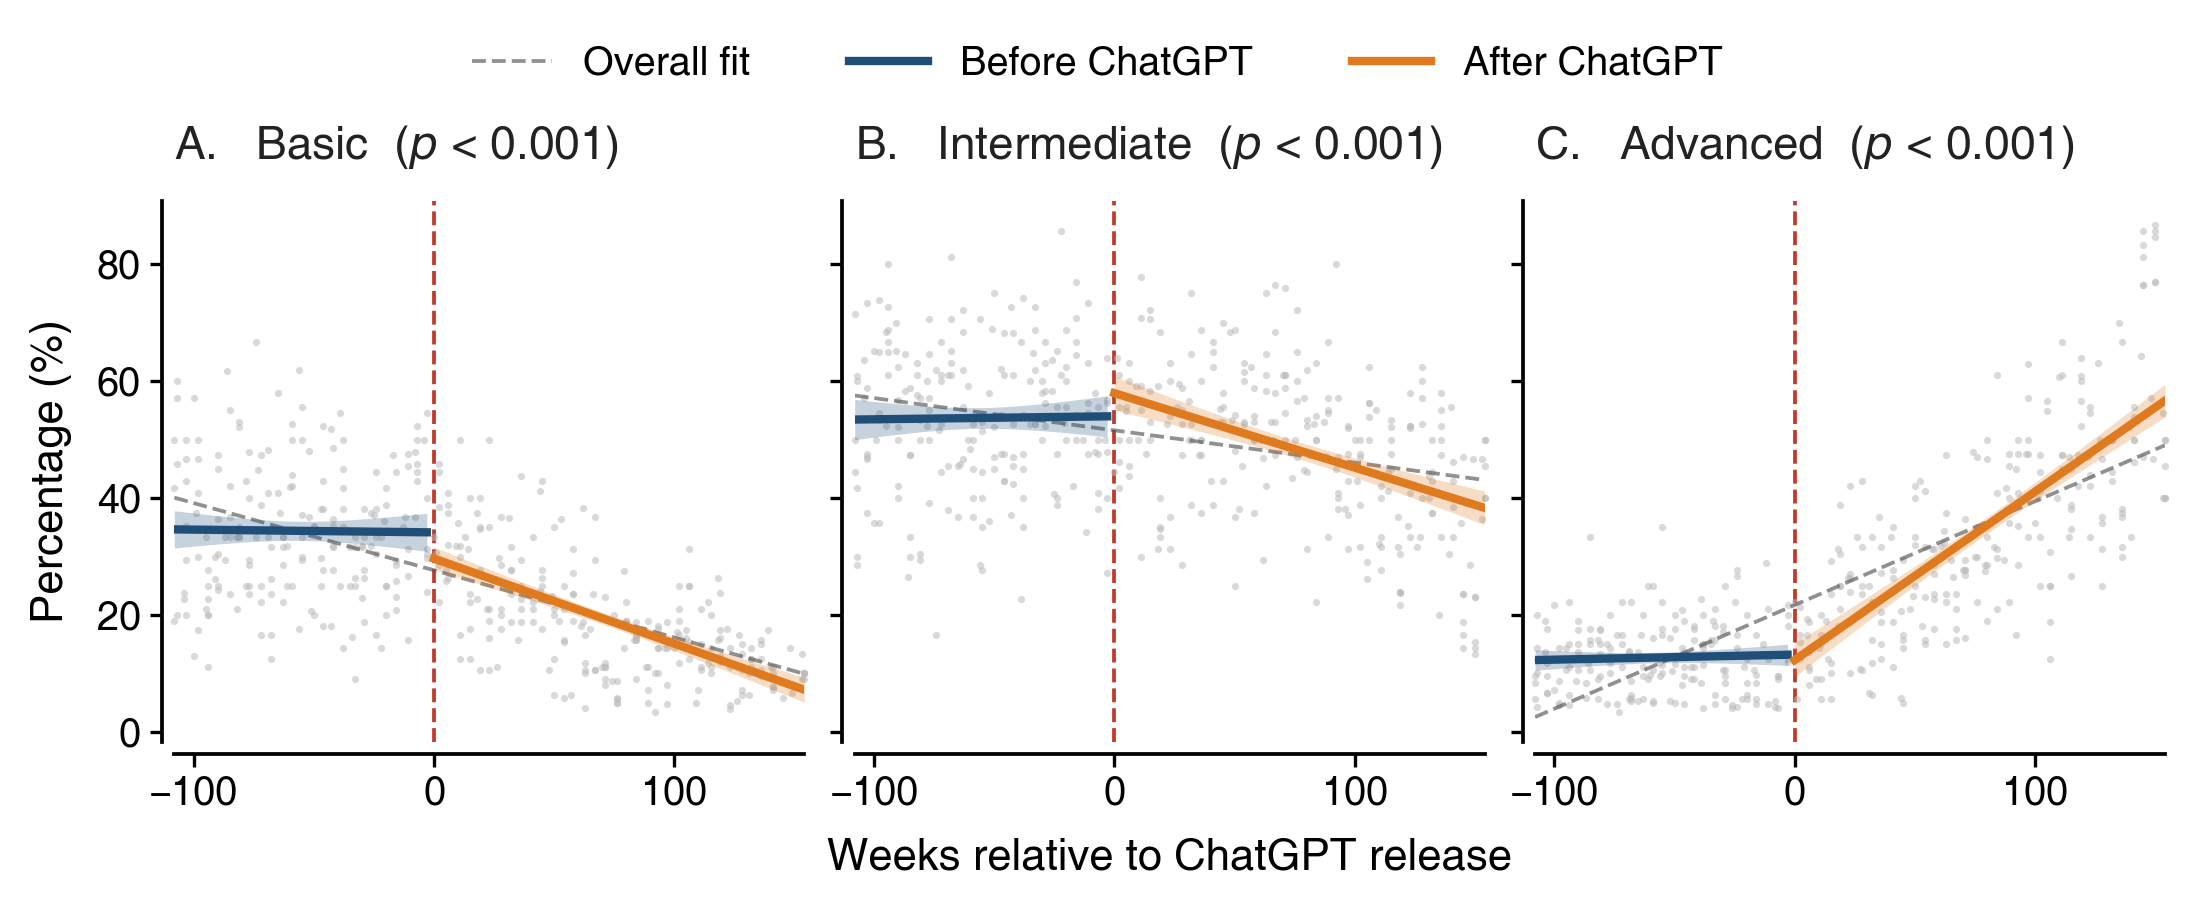

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.6), constrained_layout=True,  dpi=300, sharey=True)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        ax[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=f"{label}"
    )


ax[1].set_xlabel("Weeks relative to ChatGPT release",
                fontsize=10.5, labelpad=6)
ax[0].set_ylabel("Percentage (%)",
                fontsize=10.5, labelpad=6)
        

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False, fontsize=9.5,
    handlelength=2.0, columnspacing=2.5
)


plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure_horizontal_3panel.png'

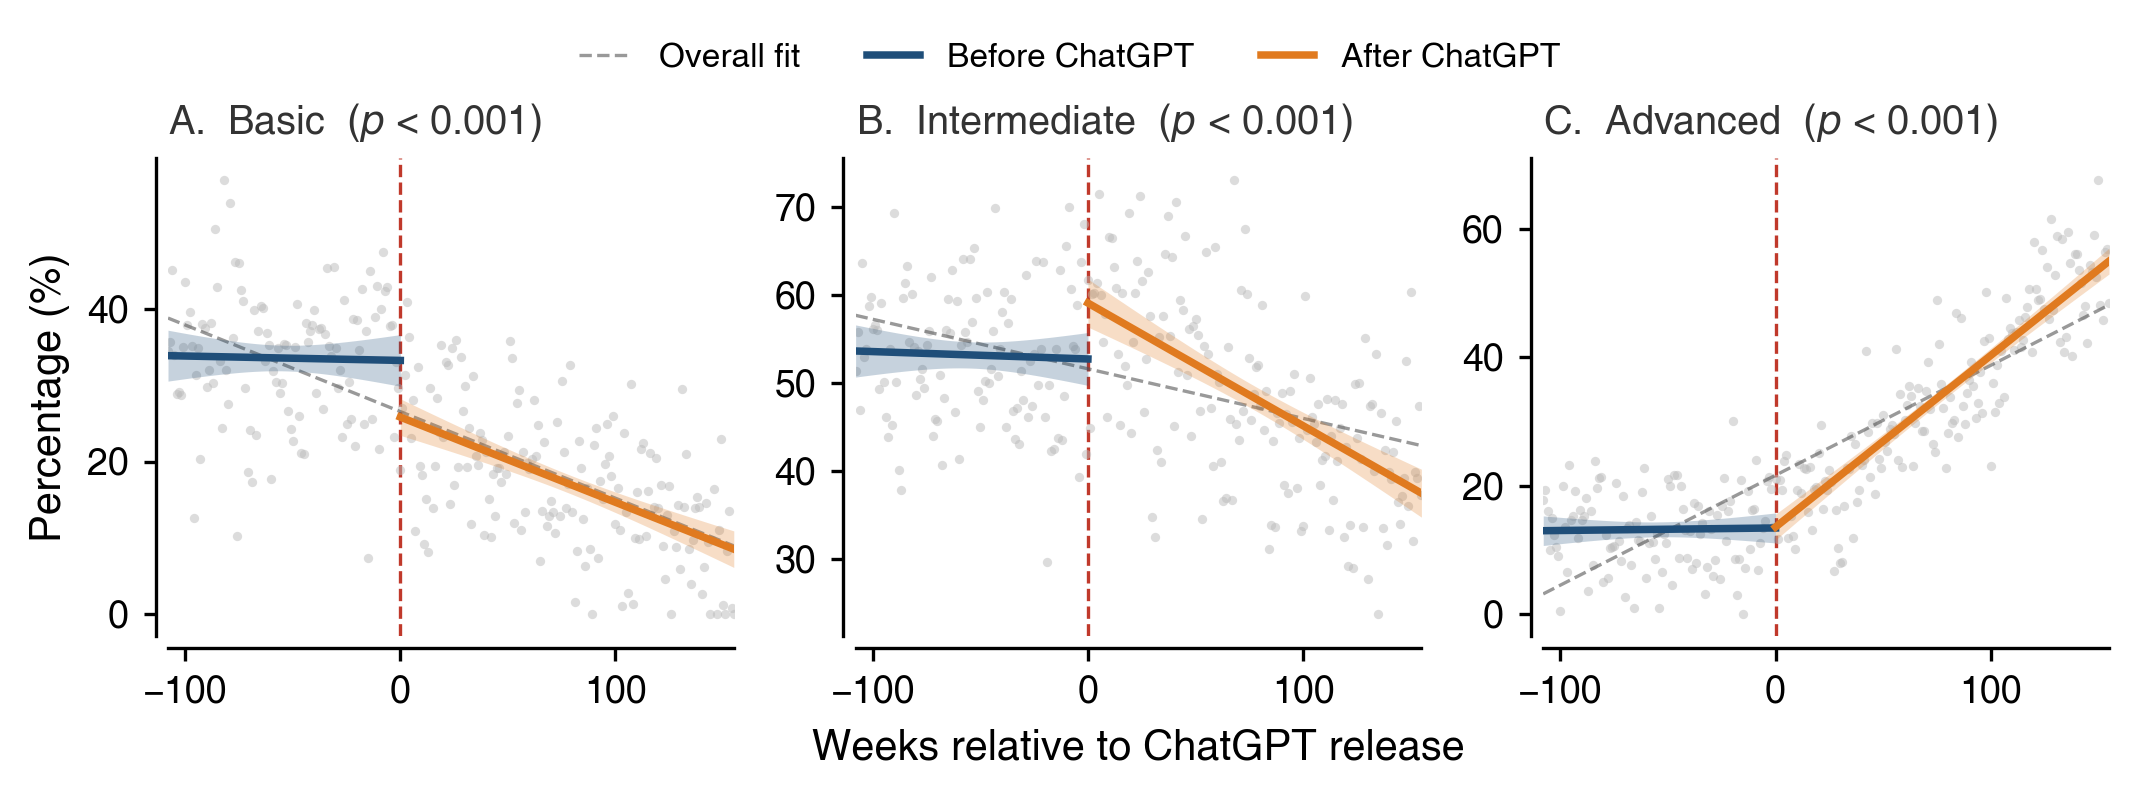

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from scipy.stats import f as f_dist

PALETTE = {'primary':'#1f4e79','accent':'#E07A1F','event':'#C0392B','neutral':'#555555','point':'#BBBBBB'}

mpl.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':9,'axes.linewidth':0.8,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'xtick.direction':'out','ytick.direction':'out',
    'xtick.major.width':0.8,'ytick.major.width':0.8,
    'xtick.major.size':3,'ytick.major.size':3,
    'legend.fontsize':8,'legend.frameon':False,
    'pdf.fonttype':42,'ps.fonttype':42,
})

def chow_test(x, y, bp=0):
    x=np.asarray(x); y=np.asarray(y)
    pre=x<bp; post=x>=bp; n=len(x); k=2
    s_all,i_all,*_=stats.linregress(x,y)
    rss_pool=np.sum((y-(s_all*x+i_all))**2)
    rp=stats.linregress(x[pre],y[pre]); rq=stats.linregress(x[post],y[post])
    rss_seg=np.sum((y[pre]-(rp.slope*x[pre]+rp.intercept))**2) + \
            np.sum((y[post]-(rq.slope*x[post]+rq.intercept))**2)
    F=((rss_pool-rss_seg)/k)/(rss_seg/(n-2*k))
    return 1-f_dist.cdf(F,k,n-2*k), rp, rq, (s_all,i_all)

def regression_ci(x,y,xs,alpha=0.05):
    x=np.asarray(x); y=np.asarray(y); xs=np.asarray(xs); n=len(x)
    slope,intercept,*_=stats.linregress(x,y)
    resid=y-(slope*x+intercept)
    s_err=np.sqrt(np.sum(resid**2)/(n-2))
    x_mean=x.mean(); ss_x=np.sum((x-x_mean)**2)
    t_val=stats.t.ppf(1-alpha/2,n-2)
    ci=t_val*s_err*np.sqrt(1/n+(xs-x_mean)**2/ss_x)
    fit=slope*xs+intercept
    return fit, fit-ci, fit+ci

def make_dummy(weeks, pre_lvl, post_slope, post_intercept, noise=8):
    rng=np.random.default_rng(abs(int(pre_lvl*100))+42)
    pre=pre_lvl+rng.normal(0,noise,np.sum(weeks<0))
    post=post_intercept+post_slope*weeks[weeks>=0]+rng.normal(0,noise,np.sum(weeks>=0))
    return pd.DataFrame({'rel_week':weeks,
                         'percentage':np.clip(np.concatenate([pre,post]),0,100)})

weeks=np.arange(-108,156)
df_basic=make_dummy(weeks,35,-0.13,28,8)
df_inter=make_dummy(weeks,54,-0.13,58,8)
df_adv=make_dummy(weeks,13,0.28,12,6)

def plot_panel(ax,df,title,panel_lbl,show_ylabel=False,show_xlabel=False):
    df=df.sort_values('rel_week').reset_index(drop=True)
    x=df['rel_week'].values; y=df['percentage'].values.astype(float)
    pre=x<0; post=x>=0
    p_chow,_,_,(s_all,i_all)=chow_test(x,y,0)
    ax.scatter(x,y,s=5,color=PALETTE['point'],alpha=0.5,lw=0,zorder=2)
    xs_all=np.linspace(x.min(),x.max(),100)
    ax.plot(xs_all,s_all*xs_all+i_all,color=PALETTE['neutral'],
            lw=0.8,ls='--',alpha=0.6,zorder=3,label='Overall fit')
    xs_pre=np.linspace(x[pre].min(),0,100)
    xs_post=np.linspace(0,x[post].max(),100)
    fit_pre,lo_pre,hi_pre=regression_ci(x[pre],y[pre],xs_pre)
    fit_post,lo_post,hi_post=regression_ci(x[post],y[post],xs_post)
    ax.fill_between(xs_pre,lo_pre,hi_pre,color=PALETTE['primary'],alpha=0.25,lw=0,zorder=4)
    ax.plot(xs_pre,fit_pre,color=PALETTE['primary'],lw=1.8,zorder=5,label='Before ChatGPT')
    ax.fill_between(xs_post,lo_post,hi_post,color=PALETTE['accent'],alpha=0.25,lw=0,zorder=4)
    ax.plot(xs_post,fit_post,color=PALETTE['accent'],lw=1.8,zorder=5,label='After ChatGPT')
    ax.axvline(0,color=PALETTE['event'],lw=0.8,ls='--',zorder=1)
    p_text='$p$ < 0.001' if p_chow<0.001 else f'$p$ = {p_chow:.3f}'
    ax.set_title(f'{panel_lbl}.  {title}  ({p_text})',
                 fontsize=9.5,loc='left',pad=6,color='#333')
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_position(('outward',3))
    ax.spines['bottom'].set_position(('outward',3))
    ax.set_xlim(x.min(),x.max())
    ax.grid(False)
    if show_ylabel:
        ax.set_ylabel('Percentage (%)')
    if show_xlabel:
        ax.set_xlabel('Weeks relative to ChatGPT release')

# 가로 1x3 — Science double column 폭 (약 180mm = 7.1")
fig,axes=plt.subplots(1,3,figsize=(7.2,2.6),dpi=300)
plot_panel(axes[0],df_basic,'Basic',       'A',show_ylabel=True, show_xlabel=False)
plot_panel(axes[1],df_inter,'Intermediate','B',show_ylabel=False,show_xlabel=True)
plot_panel(axes[2],df_adv,  'Advanced',    'C',show_ylabel=False,show_xlabel=False)

# 범례 한 번만 — figure 상단
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,1.02),
           ncol=3,handlelength=1.6,borderpad=0.4,frameon=False,fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('/mnt/user-data/outputs/figure_horizontal_3panel.png',
            dpi=300,bbox_inches='tight',facecolor='white')

In [ ]:


mpl.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':9,'axes.linewidth':0.8,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'xtick.direction':'out','ytick.direction':'out',
    'xtick.major.width':0.8,'ytick.major.width':0.8,
    'xtick.major.size':3,'ytick.major.size':3,
    'legend.fontsize':8,'legend.frameon':False,
    'pdf.fonttype':42,'ps.fonttype':42,
})

def chow_test(x, y, bp=0):
    x=np.asarray(x); y=np.asarray(y)
    pre=x<bp; post=x>=bp; n=len(x); k=2
    s_all,i_all,*_=stats.linregress(x,y)
    rss_pool=np.sum((y-(s_all*x+i_all))**2)
    rp=stats.linregress(x[pre],y[pre]); rq=stats.linregress(x[post],y[post])
    rss_seg=np.sum((y[pre]-(rp.slope*x[pre]+rp.intercept))**2) + \
            np.sum((y[post]-(rq.slope*x[post]+rq.intercept))**2)
    F=((rss_pool-rss_seg)/k)/(rss_seg/(n-2*k))
    return 1-f_dist.cdf(F,k,n-2*k), rp, rq, (s_all,i_all)

def regression_ci(x,y,xs,alpha=0.05):
    x=np.asarray(x); y=np.asarray(y); xs=np.asarray(xs); n=len(x)
    slope,intercept,*_=stats.linregress(x,y)
    resid=y-(slope*x+intercept)
    s_err=np.sqrt(np.sum(resid**2)/(n-2))
    x_mean=x.mean(); ss_x=np.sum((x-x_mean)**2)
    t_val=stats.t.ppf(1-alpha/2,n-2)
    ci=t_val*s_err*np.sqrt(1/n+(xs-x_mean)**2/ss_x)
    fit=slope*xs+intercept
    return fit, fit-ci, fit+ci